In [2]:
import pickle

# Load the trained model
with open("../model/sarimax_model.pkl", "rb") as file:
    model = pickle.load(file)


In [3]:
import pandas as pd

# Load the cleaned TSLA data
tsla_data = pd.read_csv("../data/TSLA_cleaned.csv", index_col="Date", parse_dates=True)

# Use the 'Close' column for forecasting
tsla_close = tsla_data['Close']

# Display the first few rows
print(tsla_data.head())

                Close       High        Low       Open    Volume
Date                                                            
2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.253333  14.000667  14.187333  51637500
2015-01-09  13.777333  13.998667  13.664000  13.928000  70024500


In [4]:
import pandas as pd

# Define forecast horizon (126 business days for ~6 months)
forecast_steps = 126

# Generate forecast
forecast = model.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=tsla_close.index[-1], periods=forecast_steps + 1, freq="B")[1:]

# Extract forecasted values and confidence intervals
predicted_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Convert predictions to a DataFrame
forecast_df = pd.DataFrame({
    "Forecast": predicted_mean.values,
    "Lower Bound": conf_int.iloc[:, 0].values,
    "Upper Bound": conf_int.iloc[:, 1].values
}, index=forecast_index)

# Display first few rows
print(forecast_df.head())


              Forecast  Lower Bound  Upper Bound
2025-01-31  143.014965   132.317940   153.711990
2025-02-03  141.989397   127.015024   156.963769
2025-02-04  143.432374   125.028765   161.835983
2025-02-05  143.604400   122.394655   164.814145
2025-02-06  142.517949   118.489137   166.546761


c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


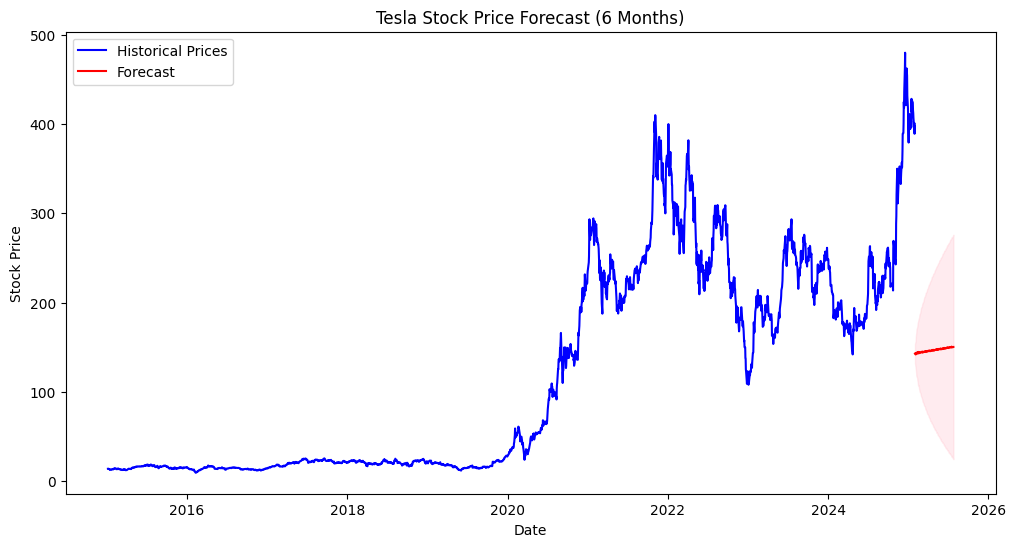

In [5]:
import matplotlib.pyplot as plt

# Plot historical data
plt.figure(figsize=(12, 6))
plt.plot(tsla_close, label="Historical Prices", color="blue")

# Plot forecasted values
plt.plot(forecast_df.index, forecast_df["Forecast"], label="Forecast", color="red")

# Plot confidence intervals
plt.fill_between(forecast_df.index, forecast_df["Lower Bound"], forecast_df["Upper Bound"], color="pink", alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Tesla Stock Price Forecast (6 Months)")
plt.legend()
plt.show()

In [6]:
# Forecast 12 months (252 business days)
future_steps = 252  # Approx. 12 months of trading days
forecast = model.get_forecast(steps=future_steps)

# Extract forecasted values and confidence intervals
forecast_values = forecast.predicted_mean
conf_int = forecast.conf_int()

# Display the first few forecasted values
forecast_df = pd.DataFrame({
    "Forecast": forecast_values,
    "Lower Bound": conf_int.iloc[:, 0],
    "Upper Bound": conf_int.iloc[:, 1]
})

print(forecast_df.head())


        Forecast  Lower Bound  Upper Bound
2027  143.014965   132.317940   153.711990
2028  141.989397   127.015024   156.963769
2029  143.432374   125.028765   161.835983
2030  143.604400   122.394655   164.814145
2031  142.517949   118.489137   166.546761


c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


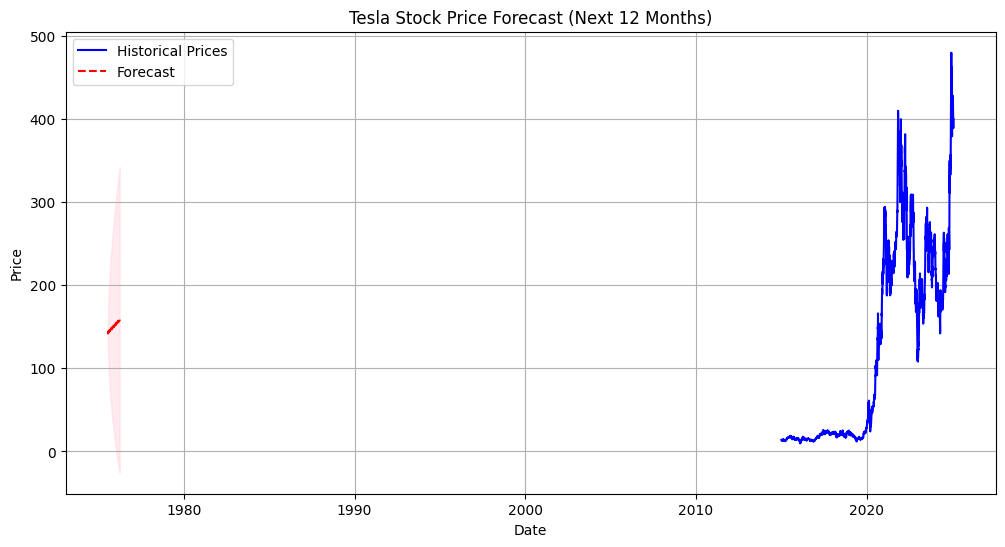

In [7]:
import matplotlib.pyplot as plt

# Plot historical and forecasted data
plt.figure(figsize=(12, 6))
plt.plot(tsla_close, label="Historical Prices", color="blue")
plt.plot(forecast_values, label="Forecast", color="red", linestyle="dashed")
plt.fill_between(forecast_values.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)

plt.title("Tesla Stock Price Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()
